#### This notebook acts as a sanity check for the source extraction and source association. 
It contains the code to run the source extraction using TRAP on single snapshot images (specifically used for LINC images from LoTSS DR3), visualising the association and a field. 

In [1]:
import os
import trap
from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
import astropy.units as u
from astropy.coordinates import SkyCoord
import astropy.coordinates as coord
from astropy.stats import sigma_clip
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import glob


### Settings for source association


In [2]:
surpress_duplications = True

### Settings for Trap


In [3]:
# If overwrite is 'false', trap will import the excisting database. If 'true' Trap will run again.
overwrite = 'true'

# [extraction]
ew_sys_err = 0
ns_sys_err = 0
detection_threshold = 8
analysis_threshold = 3
deblend_nthresh = 0
max_nr_consecutive_force_fits = 10
force_beam = True

# [extraction.image]
im_margin = 0
im_radius = 1500
im_back_size_x = 50
im_back_size_y = 50

In [4]:
random_state = 42

# Change
Path = '/scratch/tswinkels/build_classification_model/'
# while name stays the same, no updates to save time.
name = 'LINCtest'

Cataloguepath = Path+'PyBDSF_source_catalog.fits' # Might need to change this depending on the catalogue
pybdsf_cols = ['Total_flux', 'E_Total_flux', 'RA', 'E_RA', 'DEC', 'E_DEC', 'S_Code'] # Might need to change this depending on the catalogue
ImagePath = Path+'images/P3*.fits'

# Create rest of paths automatically
rmsPath = Path+'data/'+name+'_rms.csv'
tomlPath = Path+'trap_config_'+name+'.toml'
dbpath = Path+name+'_db'
MatchPath = Path+'data/persistings_mapping.csv'

## CATALOGUE

In [5]:
# Open the catalog
with fits.open(Cataloguepath) as hdul:
    hdul.info()
    # print(hdul[1].columns)
    catalogue_table = Table(hdul[1].data)
    catalogue_wcs = WCS(hdul[1].header)

Filename: /scratch/tswinkels/build_classification_model/PyBDSF_source_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (7052,)   uint8   
  1  LoTSS_DR3_srl    1 BinTableHDU     90   13667877R x 27C   [22A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, A, K, D]   


In [6]:
# Match to expected trap output
catalogue = catalogue_table[pybdsf_cols].to_pandas()
catalogue = catalogue.rename(columns={"RA": "ra", "E_RA": "uncertainty_ew", "DEC": "dec", "E_DEC": "uncertainty_ns"})
catalogue["uncertainty_ew"] /= 3600
catalogue["uncertainty_ns"] /= 3600
catalogue["E_Total_flux"] /= 1000
catalogue["Total_flux"] /= 1000


print(catalogue.shape)

(13667877, 7)


## RMS
This method adapted from Antoia Rowlinson is used to filter out fields with high RMS.\
https://github.com/AntoniaR/TraP_filter_demo/blob/main/FilterNewTraP.ipynb

In [7]:
nBins = 50 
# the number of bins to be used in the rms analysis
randomPercentage = 1 #0.01
# This is the percentage of the data you want to use for the quality control steps
sigmaClip = 3 # This is the sigma clip used to remove sources from the rms calculation. 
# Usually 3 is used in TraP (see rms_est_sigma in the job_config)
f = 8 # This is the fraction of the image that will be used for the rms calculation.
# Usually 8 is used in TraP.
#### Method needs updating to match new TraP parameter
sigmaRej = 3 # This is the rejection sigma for bad images.
# If the image is deviant from the mean by more than this value (positive or negative) the image is rejected.

In [8]:
imageList = glob.glob(ImagePath)
numImages = len(imageList)
randomImages = random.sample(imageList,int(randomPercentage*numImages))
print(len(randomImages))
numImages

66


66

In [9]:
from helperfunctions.getRMS import read_data, rms_with_clipped_subregion

if os.path.exists(rmsPath):
    imageData = pd.read_csv(rmsPath)
else:
    imageData=[]
    ### code idea - this could be paralellised to increase speed
    for filename in imageList:
        data = read_data(fits.open(filename)[0],filename, plane=None)
        imageData.append([filename, rms_with_clipped_subregion(data, sigmaClip, f)*1000.])

    imageData = pd.DataFrame(imageData, columns=['filename','rms'])
    imageData.to_csv(rmsPath)
#imageData

Text(0, 0.5, 'Number of images')

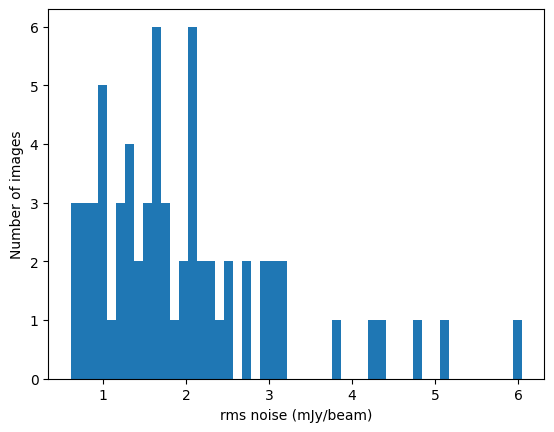

In [10]:
plt.hist(imageData.rms,bins=nBins,histtype='stepfilled')
plt.xlabel('rms noise (mJy/beam)')
plt.ylabel('Number of images')

In [11]:
def res(p, y, x):
# calculate residuals between data and Gaussian model
  m1, sd1, a = p
  y_fit = a*norm2(x, m1, sd1)
  err = y - y_fit
  return err

def guess_p(x):
# estimate the mean and rms as initial inputs to the Gaussian fitting
    median = np.median(x)
    temp=[n*n-(median*median) for n in x]
    rms = math.sqrt((abs(sum(temp))/len(x)))
    return [median, rms, math.sqrt(len(x))]

def norm2(x, mean, sd):
# creates a normal distribution in a simple array for plotting
    normdist = []
    for i in range(len(x)):
        normdist += [1.0/(sd*np.sqrt(2*np.pi))*np.exp(-(x[i] - mean)**2/(2*sd**2))]
    return np.array(normdist)

In [12]:
from scipy.optimize import leastsq
import math

# Obtain the data in a binned histogram for fitting
hist_rms=np.histogram(imageData.rms,bins=nBins)
range_x=[hist_rms[1][n]+(hist_rms[1][n+1]-hist_rms[1][n])/2. for n in range(len(hist_rms[1])-1)]

# Guess the mean and standard deviation based upon the median value
p = guess_p(imageData.rms)
print(p)

# Calculate the best fitting Gaussian distribution
plsq = leastsq(res, p, args = (hist_rms[0], range_x)) # fit Gaussian to data
fit2 = plsq[0][2]*norm2(range_x, plsq[0][0], plsq[0][1]) # create Gaussian distribution for plotting on graph

[1.7183675259001912, 1.5036234236810522, 8.12403840463596]


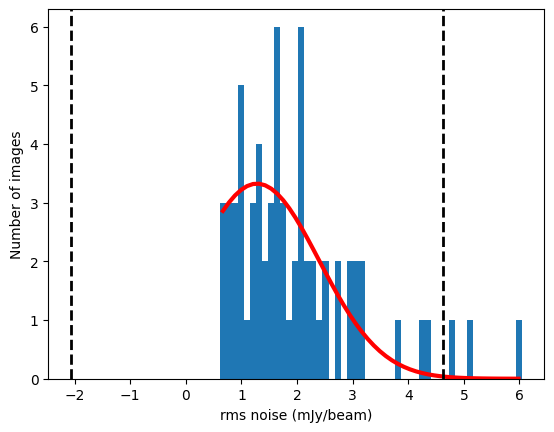

In [13]:
# Create a plot of the results

plt.plot(range_x,fit2, 'r-', linewidth=3)
plt.hist(imageData.rms,bins=nBins,histtype='stepfilled')

sigcut=plsq[0][0]+plsq[0][1]*sigmaRej # max threshold defined as (mean + RMS * sigma)
sigcut2=plsq[0][0]-plsq[0][1]*sigmaRej # min threshold defined as (mean - RMS * sigma)
plt.axvline(x=sigcut, linewidth=2, color='k',linestyle='--')
plt.axvline(x=sigcut2, linewidth=2, color='k', linestyle='--')

plt.xlabel('rms noise (mJy/beam)')
plt.ylabel('Number of images')
plt.show()

In [14]:
# Thresholds for TraP job parameters file (job_params.cfg):
rms_est_max=np.round(sigcut/1e3,6)
rms_est_min=np.round(sigcut2/1e3,6)
print('rms_est_max = '+ str(rms_est_max))
print('rms_est_min = '+ str(rms_est_min))

rms_est_max = 0.004631
rms_est_min = -0.002071


In [15]:
imageData = imageData[(imageData.rms < rms_est_max*1e3) & (imageData.rms > rms_est_min*1e3)]
newlist = imageData.filename.tolist()
randomImages=[x for x in randomImages if x in newlist]

## TRAP SOURCES

This method is adapted from TRAP. Since no consecutive snapshots are used, we only need to run the source extraction part of TRAP:

In [16]:
from helperfunctions.source_extraction import read_pyse_image, sources_from_fits_pyse
from helperfunctions.io import init_db, export_to_database
from typing import List
import dask

if overwrite == 'true':
    db_kwargs = dict(
        db_backend= "sqlite",
        db_name= dbpath,
        )
    pyse_config = dict(
                    margin=im_margin,
                    radius=im_radius,
                    back_size_x=im_back_size_x,
                    back_size_y=im_back_size_y,
                    force_beam=force_beam,
                    ew_sys_err=ew_sys_err,
                    ns_sys_err=ns_sys_err,
                    detection_thr=detection_threshold,
                    analysis_thr=analysis_threshold,
                    deblend_nthresh=deblend_nthresh,
                )
    
    db_engine = init_db(**db_kwargs, db_overwrite = overwrite)
    params_for_db = {**db_kwargs,**pyse_config}
    for key, val in params_for_db.items():
        if hasattr(val, "__len__") and not isinstance(val, str):
            params_for_db[key] = "; ".join(params_for_db[key])
    pd.DataFrame(params_for_db, index=[0]).to_sql("config", db_engine, index=False)
    
    
    dask.config.set(scheduler="threads")
    dask.config.set(num_workers=4)
    dask.config.set(pool=None)  # Ensure it respects num_workers
    
    # Turn functions representing the core steps into delayed functions
    read_pyse_image_delayed = dask.delayed(read_pyse_image, nout=3)
    sources_from_fits_pyse_delayed = dask.delayed(sources_from_fits_pyse)
    export_to_database_delayed = dask.delayed(export_to_database)
    
    # Start with first image to initiate, then loop over all other images to process
    for row in imageData.itertuples(index=False):
        rms = row.rms
        path = row.filename
        im = path.split('/')[-1]
        im_id = im.split('-')[0]
        
        pyse_im, im_meta, rejected = read_pyse_image_delayed(str(path), **pyse_config)
        new_sources = sources_from_fits_pyse_delayed(pyse_im, im_id, rms, rejected=rejected)
        db_kwargs_delayed = export_to_database_delayed(db_kwargs, im_id, rms, im_meta, new_sources)
    
        dask.compute(db_kwargs_delayed, traverse=False)


2026-02-05 11:01:22,128 - TraP - INFO - Establishing sqlite database connection for '/scratch/tswinkels/build_classification_model/LINCtest_db' (io.py:250)


End time not specified in /scratch/tswinkels/build_classification_model/images/P343+46-MFS-image.fits, setting to start


2026-02-05 11:01:26,073 - TraP - INFO - Function `read_pyse_image` took 3.367945335805416 seconds (log.py:133)
Number of detected sources = 1913
2026-02-05 11:01:26,617 - TraP - INFO - Found 1913 sources (source_extraction.py:386)
2026-02-05 11:01:26,619 - TraP - INFO - Function `sources_from_fits_pyse` took 0.5416455864906311 seconds (log.py:133)
2026-02-05 11:01:26,621 - TraP - INFO - Establishing sqlite database connection for '/scratch/tswinkels/build_classification_model/LINCtest_db' (io.py:336)


End time not specified in /scratch/tswinkels/build_classification_model/images/P300+56-MFS-image.fits, setting to start


2026-02-05 11:01:27,285 - TraP - INFO - Function `read_pyse_image` took 0.5442149639129639 seconds (log.py:133)
Number of detected sources = 2173
2026-02-05 11:01:27,830 - TraP - INFO - Found 2173 sources (source_extraction.py:386)
2026-02-05 11:01:27,832 - TraP - INFO - Function `sources_from_fits_pyse` took 0.5391386970877647 seconds (log.py:133)
2026-02-05 11:01:27,836 - TraP - INFO - Establishing sqlite database connection for '/scratch/tswinkels/build_classification_model/LINCtest_db' (io.py:336)


...

2026-02-05 11:02:26,859 - TraP - INFO - Function `read_pyse_image` took 0.45724373310804367 seconds (log.py:133)
Number of detected sources = 1231
2026-02-05 11:02:27,377 - TraP - INFO - Found 1231 sources (source_extraction.py:386)
2026-02-05 11:02:27,380 - TraP - INFO - Function `sources_from_fits_pyse` took 0.517922654747963 seconds (log.py:133)
2026-02-05 11:02:27,382 - TraP - INFO - Establishing sqlite database connection for '/scratch/tswinkels/build_classification_model/LINCtest_db' (io.py:336)


End time not specified in /scratch/tswinkels/build_classification_model/images/P321+18-MFS-image.fits, setting to start


2026-02-05 11:02:27,888 - TraP - INFO - Function `read_pyse_image` took 0.41153285652399063 seconds (log.py:133)
Number of detected sources = 550
2026-02-05 11:02:28,316 - TraP - INFO - Found 550 sources (source_extraction.py:386)
2026-02-05 11:02:28,318 - TraP - INFO - Function `sources_from_fits_pyse` took 0.4242359548807144 seconds (log.py:133)
2026-02-05 11:02:28,320 - TraP - INFO - Establishing sqlite database connection for '/scratch/tswinkels/build_classification_model/LINCtest_db' (io.py:336)


End time not specified in /scratch/tswinkels/build_classification_model/images/P332+56-MFS-image.fits, setting to start


2026-02-05 11:02:28,819 - TraP - INFO - Function `read_pyse_image` took 0.43884705007076263 seconds (log.py:133)
Number of detected sources = 2058
2026-02-05 11:02:29,264 - TraP - INFO - Found 2058 sources (source_extraction.py:386)
2026-02-05 11:02:29,266 - TraP - INFO - Function `sources_from_fits_pyse` took 0.4449925050139427 seconds (log.py:133)
2026-02-05 11:02:29,268 - TraP - INFO - Establishing sqlite database connection for '/scratch/tswinkels/build_classification_model/LINCtest_db' (io.py:336)


In [17]:
# Open the database
db_handle = trap.io.open_db("sqlite", dbpath)
with db_handle.connect() as conn:
    sources = pd.read_sql_query("SELECT * FROM extracted_sources", conn)
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

# Transform coordinates
coords = SkyCoord(
    ra=sources["ra"].values * u.deg,
    dec=sources["dec"].values * u.deg,
    frame="fk5"
)
sources.loc[:, "ra"] = coords.ra.deg
sources.loc[:, "dec"] = coords.dec.deg

print(len(sources['im_id'].unique()))

2026-02-05 11:02:29,400 - TraP - INFO - Establishing sqlite database connection for '/scratch/tswinkels/build_classification_model/LINCtest_db' (io.py:296)
63


In [18]:
sources.head()

,id,ra,dec,ra_fit_err,dec_fit_err,peak_flux,peak_flux_err,int_flux,int_flux_err,significance_detection_level,...,error_radius,chisq,reduced_chisq,ns_sys_err,ew_sys_err,gaussian_fit,uncertainty_ew,uncertainty_ns,im_id,rms
0,0,351.084876,46.814103,0.000688,0.000463,0.006052,0.000266,0.006052,0.000582,38.787830,...,2.385260,4478.098633,635.795288,0.0,0.0,1,0.000663,0.000663,P343+46,1.037891
1,1,351.023041,46.481841,0.001274,0.000863,0.002018,0.000241,0.002018,0.000402,9.433261,...,4.446542,552.145264,138.494202,0.0,0.0,1,0.001235,0.001235,P343+46,1.037891
2,2,351.373384,49.014753,0.000440,0.000284,0.010055,0.000216,0.010055,0.000569,43.384163,...,1.460141,3972.023193,321.387024,0.0,0.0,1,0.000406,0.000406,P343+46,1.037891
3,3,350.584481,44.764520,0.000855,0.000597,0.003567,0.000233,0.003567,0.000457,15.005288,...,3.080744,474.828247,96.568245,0.0,0.0,1,0.000856,0.000856,P343+46,1.037891
4,4,351.082041,48.411737,0.000789,0.000516,0.004475,0.000232,0.004475,0.000485,24.752150,...,2.651738,1585.460327,192.425751,0.0,0.0,1,0.000737,0.000737,P343+46,1.037891


In [19]:
catalogue.head()

,Total_flux,E_Total_flux,ra,uncertainty_ew,dec,uncertainty_ns,S_Code
0,0.008356,0.000748,0.000029,0.000235,37.227717,0.000167,M
1,0.000807,0.000242,0.000047,0.000228,19.864351,0.000130,S
2,0.000851,0.000261,0.000060,0.000204,21.542338,0.000226,S
3,0.001051,0.000308,0.000077,0.000262,29.923839,0.000180,S
4,0.001307,0.000407,0.000087,0.000338,48.865857,0.000777,M


## ASSOCIATION

This method makes use of the source association of trap to associate the catalog with the found sources:\
https://git.astron.nl/RD/trap

In [20]:
from helperfunctions.associate import associate
"""
input:
sources,new_sources
output:
null_detection_ids: the ids corresponding to `new_sources.index` that were not found in sources
new_source_ids: the ids corresponding to `sources.index` that were in new_sources but not in the original sources
persistings_mapping: :class:`pd.DataFrame`: A dataframe containing the columns `[original_id, new_id, de_ruiter]` that map the indices
    from sources to new_sources of those that are identified as being a persistant source, 
    meaning it is a source that occurs in both sourcse lists.
duplicate_mapping: A dataframe containing the columns `[original_id, new_id, de_ruiter]` that map the indices 
    of any access sources in new_sources to the nearest source in the original sources DataFrame.
"""

if not os.path.exists(MatchPath):
    null_detection_ids, new_source_ids, persistings_mapping, duplicate_mapping = associate(catalogue, sources, surpress_duplications=False)
    persistings_mapping.to_csv(MatchPath)
else:
    persistings_mapping = pd.read_csv(MatchPath)

In [21]:
# Create two dataframes that contain same sources per index
matched_catalogue = catalogue.loc[persistings_mapping['original_id'].values].reset_index(drop=True)
matched_sources = sources.loc[persistings_mapping['new_id'].values].reset_index(drop=True)
matched_sources.head()

,id,ra,dec,ra_fit_err,dec_fit_err,peak_flux,peak_flux_err,int_flux,int_flux_err,significance_detection_level,...,error_radius,chisq,reduced_chisq,ns_sys_err,ew_sys_err,gaussian_fit,uncertainty_ew,uncertainty_ns,im_id,rms
0,2,351.373384,49.014753,0.000440,0.000284,0.010055,0.000216,0.010055,0.000569,43.384163,...,1.460141,3972.023193,321.387024,0.0,0.0,1,0.000406,0.000406,P343+46,1.037891
1,37,349.450757,45.208924,0.000099,0.000068,0.147672,0.000480,0.147672,0.001928,300.680664,...,0.352753,32435.291016,1129.961304,0.0,0.0,1,0.000098,0.000098,P343+46,1.037891
2,144,348.179084,47.469006,0.000733,0.000489,0.024066,0.001145,0.024066,0.002449,23.774853,...,2.509365,3805.546143,392.277710,0.0,0.0,1,0.000697,0.000697,P343+46,1.037891
3,168,347.700133,43.711252,0.001063,0.000758,0.003446,0.000329,0.003446,0.000582,10.259984,...,3.894619,205.031418,46.752625,0.0,0.0,1,0.001082,0.001082,P343+46,1.037891
4,206,347.474862,44.196579,0.000143,0.000101,0.108423,0.000577,0.108423,0.002102,170.149353,...,0.520644,29364.425781,2166.311279,0.0,0.0,1,0.000145,0.000145,P343+46,1.037891


In [22]:
matched_catalogue.head()

,Total_flux,E_Total_flux,ra,uncertainty_ew,dec,uncertainty_ns,S_Code
0,1.447876,0.001909,351.374382,1.566856e-06,49.014162,5.889046e-07,M
1,3.459487,0.008826,349.451419,5.479603e-07,45.208631,6.931048e-07,M
2,0.018346,0.000324,348.180352,8.562584e-06,47.468711,8.109447e-06,S
3,0.066755,0.001696,347.702677,6.045865e-05,43.707565,7.983681e-05,M
4,0.880684,0.003355,347.473997,1.176294e-05,44.197095,1.621904e-05,M


In [23]:
# Remove sources labeld other then S or M
if len(pd.unique(matched_catalogue.get('S_Code', ''))) > 2:
    mask = matched_catalogue.get('S_Code', '').isin(['S','M'])
    matched_catalogue = matched_catalogue[mask]
    matched_sources = matched_sources[mask]

print(matched_catalogue['S_Code'].value_counts())

S_Code
M    26132
S     7886
Name: count, dtype: int64


In [24]:
# Functions to visualise if the source association worked
def scatter_catalogue(ax, catalogue, wcs, size, color, title, label):
    ax.set_title(title)
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    # Zoom in:
    # ax.set_xlim((241,242))
    # ax.set_ylim((54,54.5))
    
    x, y = wcs.world_to_pixel_values(catalogue['ra'],catalogue['dec'])
    ax.scatter(
        x, y,
        s=size,
        c=color,
        alpha=0.6,
        label=label)

def draw_match_lines(ax, cat1, cat2, wcs, color="gray", alpha=0.3, lw=0.7):
    x1, y1 = wcs.world_to_pixel_values(cat1['ra'], cat1['dec'])
    x2, y2 = wcs.world_to_pixel_values(cat2['ra'], cat2['dec'])
    
    for i in range(len(cat1)):
        inside1 = 242 <= x1[i] <= 243 and 54.90 <= y1[i] <= 55.10
        inside2 = 242 <= x2[i] <= 243 and 54.90 <= y2[i] <= 55.10
        
        if inside1 or inside2:
            ax.plot(
                [x1[i], x2[i]],
                [y1[i], y2[i]],
                color=color,
                alpha=alpha,
                linewidth=lw
            )

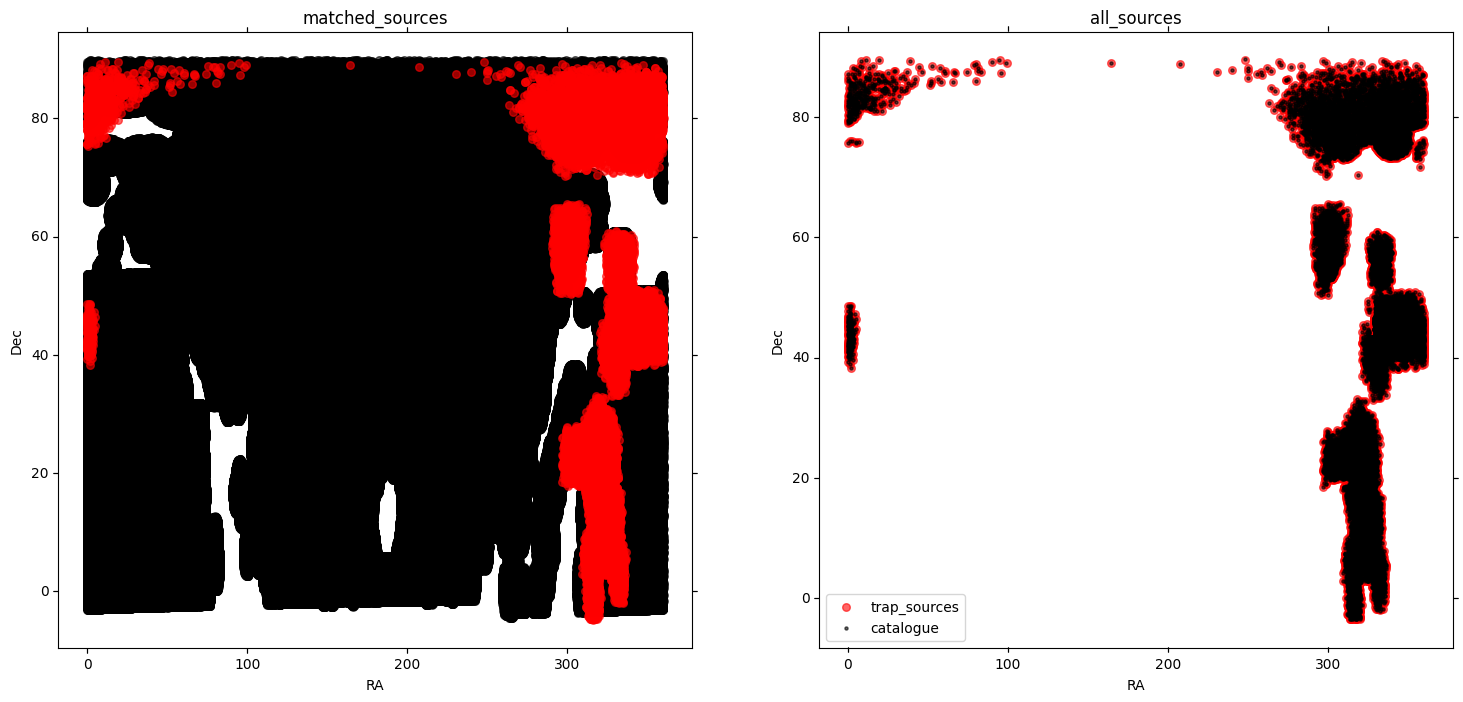

In [25]:
# Visual inspection of the source association
fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': catalogue_wcs}) 

scatter_catalogue(axes[0], catalogue, catalogue_wcs, 30, "k", "all_sources", "catalogue") 
scatter_catalogue(axes[0], sources, catalogue_wcs, 30, "r", "matched_sources", "trap_sources" ) 

scatter_catalogue(axes[1], matched_sources, catalogue_wcs, 30, "r", "matched_sources", "trap_sources" ) 
scatter_catalogue(axes[1], matched_catalogue, catalogue_wcs, 5, "k", "all_sources", "catalogue") 

# Drawing lines between the matched sources should show if the index is correct
draw_match_lines(axes[1], matched_catalogue, matched_sources, catalogue_wcs)

plt.legend()
plt.show()

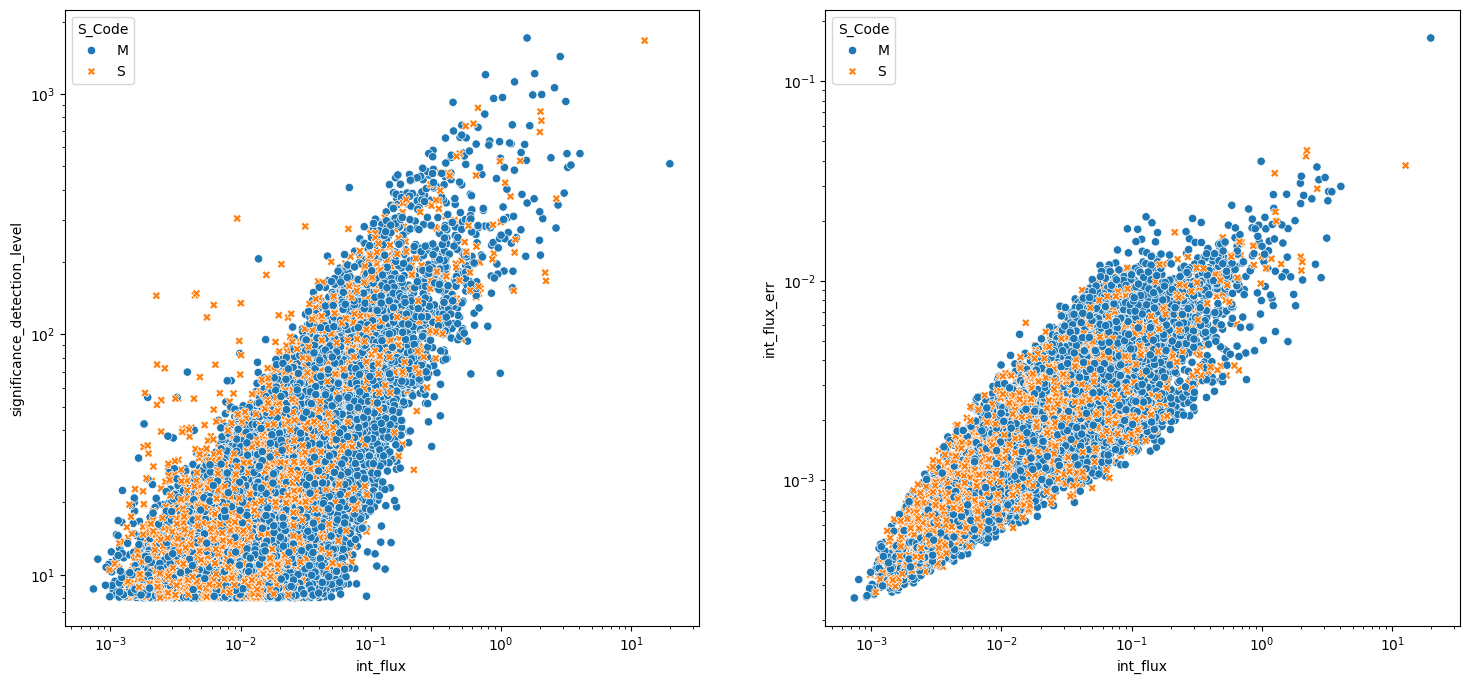

In [26]:
# Make a combined list to visualise
combined = matched_sources.copy()
combined["S_Code"] = matched_catalogue["S_Code"].values

# Some possibly intresting visualisations
fig, axes = plt.subplots(1, 2, figsize=(18, 8)) 
sns.scatterplot(data=combined, x="int_flux", y="significance_detection_level", hue="S_Code", style="S_Code", ax=axes[0])
sns.scatterplot(data=combined, x="int_flux", y="int_flux_err", hue="S_Code", style="S_Code", ax=axes[1])

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[1].set_xscale("log")
axes[1].set_yscale("log")


<Axes: xlabel='rms', ylabel='int_flux'>

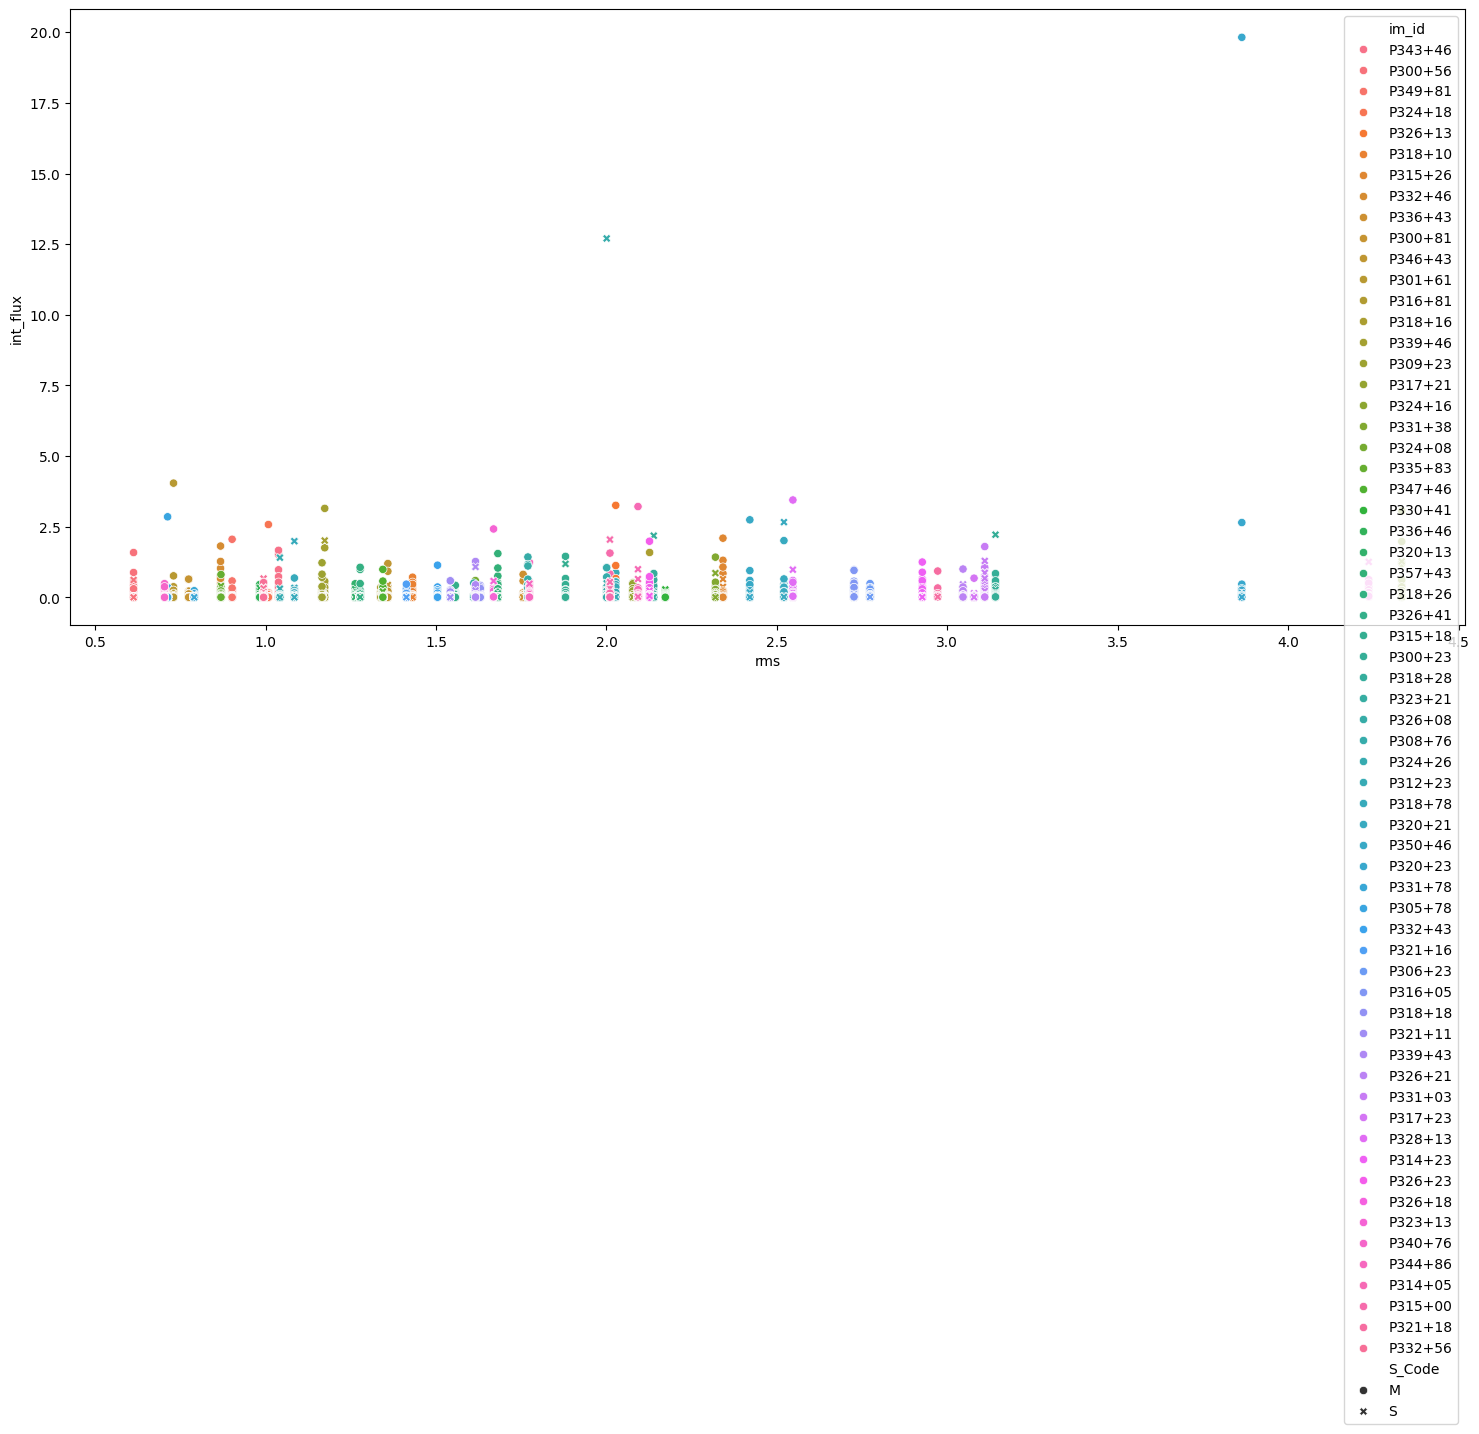

In [27]:
# Some possibly intresting visualisations
fig, axes = plt.subplots(1, 1, figsize=(18, 8)) 
sns.scatterplot(data=combined, x="rms", y="int_flux", hue="im_id", style='S_Code', ax=axes)

2026-02-05 11:32:16,208 - TraP - WARNING - FITSFixedWarning: 'datfix' made the change 'Set MJD-OBS to 60131.057894 from DATE-OBS'. (/home/tswinkels/.local/lib/python3.10/site-packages/astropy/wcs/wcs.py:807) (log.py:19)
2026-02-05 11:32:16,213 - TraP - WARNING - FITSFixedWarning: 'datfix' made the change 'Set MJD-OBS to 60131.057894 from DATE-OBS'. (/home/tswinkels/.local/lib/python3.10/site-packages/astropy/wcs/wcs.py:807) (log.py:19)
WCS Keywords

Number of WCS axes: 4
CTYPE : 'RA---SIN' 'DEC--SIN' 'FREQ' 'STOKES' 
CRVAL : -39.4066666666667 23.0569166666667 144041442.871094 1.0 
CRPIX : 1251.0 1251.0 1.0 1.0 
PC1_1 PC1_2 PC1_3 PC1_4  : 1.0 0.0 0.0 0.0 
PC2_1 PC2_2 PC2_3 PC2_4  : 0.0 1.0 0.0 0.0 
PC3_1 PC3_2 PC3_3 PC3_4  : 0.0 0.0 1.0 0.0 
PC4_1 PC4_2 PC4_3 PC4_4  : 0.0 0.0 0.0 1.0 
CDELT : -0.00416666666666667 0.00416666666666667 47656250.0 1.0 
NAXIS : 2500  2500  1  1


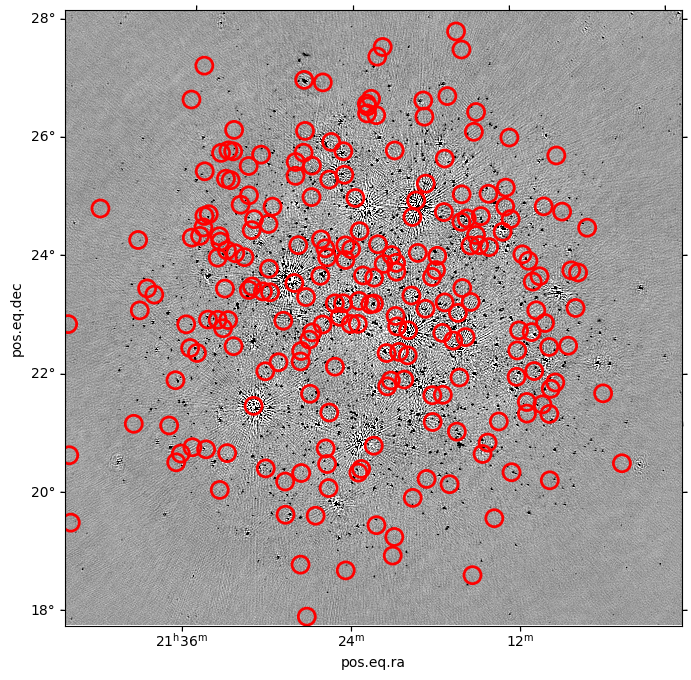

In [28]:
# Filter a random field
random_field = random.choice(matched_sources['im_id'].unique())
filtered = combined[combined["im_id"] == random_field]
coord = SkyCoord(
    ra= filtered["ra"].values * u.deg,
    dec= filtered["dec"].values * u.deg,
    frame="icrs"
)

# Open the image to extract information
with fits.open(Path+'images/'+random_field+'-MFS-image.fits') as hdul:
    wcs = WCS(hdul[0].header).celestial
    print(WCS(hdul[0].header))

image_data = fits.getdata(Path+'images/P357+43-MFS-image.fits')
image_data = image_data.squeeze()
vmin, vmax = np.nanpercentile(image_data, (1, 99))

# Plot the image with its sources
fig, axes = plt.subplots(1, 1, figsize=(18, 8), subplot_kw={'projection': wcs}) 
axes.imshow(
        image_data[2:],
        origin="lower",
        cmap="gray_r",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,)

axes.scatter(
    coord.ra.deg,
    coord.dec.deg,
    transform=axes.get_transform("world"),
    s=150,
    facecolors="none",
    edgecolors="red",
    linewidths=2
)
